In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [88]:
def feature_eda(df, col):
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f'Churn Distribution by {col}')
    plt.show()

    churn_pct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    display(churn_pct)

    contingency_table = pd.crosstab(df[col], df['Churn'])

    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    n = contingency_table.values.sum()
    v = np.sqrt(chi2/n * 1)
    print("Cramer's V value:\n")   
    print(v)

    return v

In [6]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [7]:
original_df = pd.read_csv("original_data.csv")

In [10]:
train_df["is_original"] = False
original_df["is_original"] = True

In [11]:
df = pd.concat([
    train_df, 
    original_df.drop("customerID", axis=1)
], axis=0)

In [14]:
df.isnull().any()

id                   True
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
is_original         False
dtype: bool

In [25]:
df["InternetService"].value_counts()

InternetService
Fiber optic    275482
DSL            183502
No             142253
Name: count, dtype: int64

In [30]:
df_encoded = df.apply(lambda x: x.astype('category').cat.codes if x.dtype == 'object' or bool else x)

In [15]:
key_variables_num = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [16]:
key_variables_cat = ['Partner',
 'Dependents',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen']

In [34]:
df["OnlineSecurity"].value_counts()

OnlineSecurity
No                     292972
Yes                    166012
No internet service    142253
Name: count, dtype: int64

## Feature engineering

In [38]:
df["OnlineSecurity"].value_counts()

OnlineSecurity
No                     292972
Yes                    166012
No internet service    142253
Name: count, dtype: int64

In [85]:
choices = ["yes"]

no_tech_conditions = [
    (df["PhoneService"] == "No") & 
    (df["InternetService"] == "No") 
]

phone_only_conditions = [
    (df["PhoneService"] == "Yes") & 
    (df["InternetService"] == "No") 
]

solo_senior_conditions = [
    (df["Partner"] == "No") & 
    (df["SeniorCitizen"] == 1) 
]

digital_native_conditions = [
    (df["InternetService"] == 'Fiber optic') &
    (df["StreamingTV"] == 'Yes') &
    (df["StreamingMovies"] == 'Yes')
]

ecosystem_conditions = [
    (df[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
        ] == 'Yes').sum(axis=1) >= 5]

security_bundle_conditions = [
    (df['OnlineSecurity'] == 'Yes') &
    (df['TechSupport'] == 'Yes')
]

movie_buff_conditions = [
    (df['StreamingTV'] == 'Yes') &
    (df['StreamingMovies'] == 'Yes')
]

paperless_senior_conditions = [
    (df['SeniorCitizen'] == 1) & 
    (df['PaperlessBilling'] == 'Yes')
]

family_conditions = [
    (df['Partner'] == 'Yes') &
    (df['Dependents'] == 'Yes')
]

auto_pay_conditions = [
    df['PaymentMethod'].isin(['Bank transfer (automatic)', 'Credit card (automatic)'])
]

high_risk_conditions = [
    (df['Contract'] == 'Month-to-month') &
    (df['PaymentMethod'] == 'Electronic check')
]

fiber_soloist_conditions = [
    (df['InternetService'] == 'Fiber optic') &
    (df['Partner'] == 'No') &
    (df['Dependents'] == 'No')
]

support_heavy_conditions = [
    (df['TechSupport'] == 'Yes') &
    (df['DeviceProtection'] == 'Yes')
]

basic_phone_conditions = [
    (df['InternetService'] == 'No') &
    (df['MultipleLines'] == 'Yes')
]

df["no_tech"] = np.select(no_tech_conditions, choices, default="no")
df["phone_only"] = np.select(phone_only_conditions, choices, default="no")
df["solo_senior"] = np.select(old_widow_conditions, choices, default="no")
df["digital_native"] = np.select(digital_native_conditions, choices, default="no")
df["is_high_ecosystem"] = np.select(ecosystem_conditions, choices, default="no")
df["security_bundle"] = np.select(security_bundle_conditions, choices, default="no")
df["movie_buff"] = np.select(movie_buff_conditions, choices, default="no")
df["paperless_senior"] = np.select(paperless_senior_conditions, choices, default="no")
df["is_family"] = np.select(family_conditions, choices, default="no")
df["is_automatic_payer"] = np.select(auto_pay_conditions, choices, default="no")
df["high_risk_contract"] = np.select(high_risk_conditions, choices, default="no")
df["fiber_soloist"] = np.select(fiber_soloist_conditions, choices, default="no")
df["support_heavy"] = np.select(support_heavy_conditions, choices, default="no")
df["basic_phone"] = np.select(basic_phone_conditions, choices, default="no")

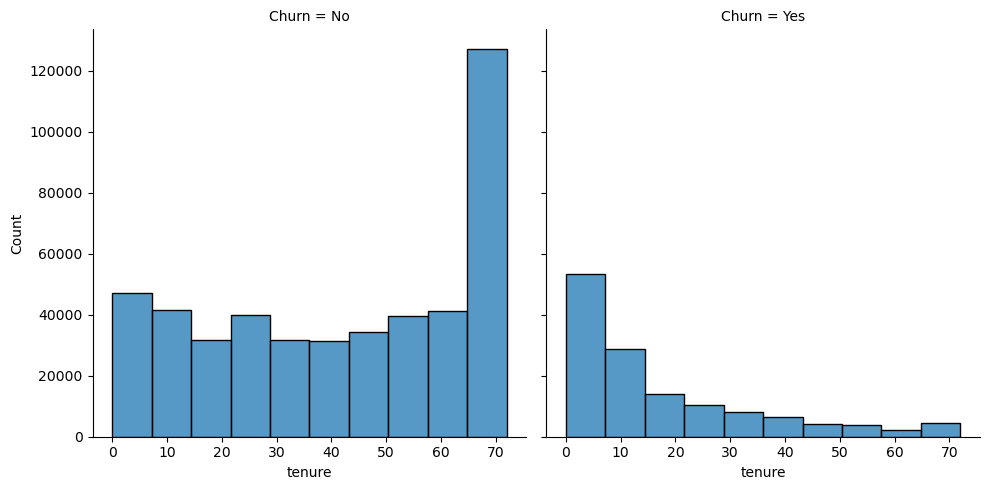

In [95]:
sns.displot(df, x='tenure', col='Churn', binwidth=7, height=5)
plt.show()

In [107]:
churn_map = {
    "No": 0,
    "Yes": 1
}

df["Churn"] = df["Churn"].map(churn_map)

In [110]:
df['tenure_cut'] = pd.qcut(df['tenure'], 10)

df.groupby(["tenure_cut"], as_index=False, observed=True)['Churn'].mean()

# need to use asymmetic binning here to capture the churn rate in month 1,2,3 4-6 6-12 etc.

,tenure_cut,Churn
0,"(-0.001, 3.0]",0.576098
1,"(3.0, 9.0]",0.455812
2,"(9.0, 16.0]",0.391281
3,"(16.0, 24.0]",0.240758
4,"(24.0, 35.0]",0.204286
5,"(35.0, 47.0]",0.144766
6,"(47.0, 56.0]",0.098371
7,"(56.0, 66.0]",0.057952
8,"(66.0, 71.0]",0.041315
9,"(71.0, 72.0]",0.017068


In [99]:
df["Churn"]

0        No
1        No
2        No
3       Yes
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 601237, dtype: object

In [91]:
df.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'is_original', 'no_tech',
       'phone_only', 'internet_only', 'old_widow', 'old_phone_only',
       'solo_senior', 'digital_native', 'is_high_ecosystem', 'security_bundle',
       'movie_buff', 'paperless_senior', 'is_family', 'is_automatic_payer',
       'high_risk_contract', 'fiber_soloist', 'support_heavy', 'basic_phone'],
      dtype='object')

In [ ]:
key_variables_num = ['tenure', 'MonthlyCharges', 'TotalCharges']